# Trabajo final de maestría
## Análisis de resoluciones de amparo como mecanismo para la detección de fallas en el proceso penal mexicano
Dana del Carmen Ramos Ramírez <br>
Erika Alicia Rojas Meza <br>
Manuel Sánchez Romero <br>
Marina Portillo Rangel <br>


In [ ]:
pip install pdfplumber

Antes de realizar el análisis exploratorio, se llevó a cabo un proceso de limpieza y normalización del texto con el fin de mejorar la calidad de los datos y facilitar la detección de patrones.
El preprocesamiento incluyó la conversión del texto a minúsculas, la eliminación de caracteres especiales, signos de puntuación y espacios innecesarios. Asimismo, se eliminaron palabras vacías (stopwords) que no aportan significado relevante al análisis, como artículos, preposiciones y conectores frecuentes.


In [3]:
#Llamamos función para leer PDF´s
import pdfplumber

def extraer_texto_pdf(ruta_pdf):
    texto = ""
    with pdfplumber.open(ruta_pdf) as pdf:
        for pagina in pdf.pages:
            texto += pagina.extract_text() or ""
    return texto

In [4]:
#Recorre todos los PDFs de la carpeta
import os
carpeta_pdfs = "C:/Users/HP_USER/Desktop/UNIR/Seminario/Amparos"
documentos = []

for archivo in os.listdir(carpeta_pdfs):
    if archivo.endswith(".pdf"):
        ruta_pdf = os.path.join(carpeta_pdfs, archivo)
        texto = extraer_texto_pdf(ruta_pdf)
        documentos.append({
            "archivo": archivo,
            "texto": texto
        })

In [5]:
#Nos muestra cuantos documentos está leyendo
len(documentos)

40

In [6]:
documentos[0]["texto"][:500]

'AMPARO DIRECTO 29/2020\nQUEJOSA: TOTAL PLAY\nTELECOMUNICACIONES,\nSOCIEDAD ANÓNIMA DE CAPITAL\nVARIABLE\nPONENTE: MINISTRO LUIS MARÍA AGUILAR MORALES\nSECRETARIO: JAVIER EDUARDO ESTREVER RAMOS\nCOLABORÓ: DIANA LAURA ROUZAUD ANAYA\nÍNDICE TEMÁTICO\nApartado Criterio y decisión Págs.\nRelación de hechos relevantes 1\nANTECEDENTES Y\nI. del asunto y trámite en este\nTRÁMITE\nTribunal Constitucional.\nLa Segunda Sala de la 5\nII. COMPETENCIA Suprema Corte de Justicia de la\nNación es competente.\nEXISTENCIA DEL ACTO '

In [7]:
#Convierte la lista de documentos a un Data Frame
import pandas as pd

df = pd.DataFrame(documentos)
df.head()

,archivo,texto
0,2_275703_6975_firmado.pdf,AMPARO DIRECTO 29/2020\nQUEJOSA: TOTAL PLAY\nT...
1,2_277422_5407_firmado.pdf,AMPARO DIRECTO 33/2020.\nQUEJOSO: EJIDO PINO G...
2,2_282000_6705_firmado.pdf,DATOS SENSIBLES\nAMPARO DIRECTO 7/2021\n(DERIV...
3,2_283663_5866_firmado.pdf,AMPARO DIRECTO 9/2021\nQUEJOSA: **********\nPO...
4,2_284030_5426_firmado.pdf,AMPARO DIRECTO 11/2021\nQUEJOSO: ÓSCAR ESQUIVE...


In [8]:
#Creamos la variable "longitud_texto" y la consultamos
df["longitud_texto"] = df["texto"].apply(lambda x: len(x.split()))
df.head()

,archivo,texto,longitud_texto
0,2_275703_6975_firmado.pdf,AMPARO DIRECTO 29/2020\nQUEJOSA: TOTAL PLAY\nT...,34750
1,2_277422_5407_firmado.pdf,AMPARO DIRECTO 33/2020.\nQUEJOSO: EJIDO PINO G...,59026
2,2_282000_6705_firmado.pdf,DATOS SENSIBLES\nAMPARO DIRECTO 7/2021\n(DERIV...,36428
3,2_283663_5866_firmado.pdf,AMPARO DIRECTO 9/2021\nQUEJOSA: **********\nPO...,10449
4,2_284030_5426_firmado.pdf,AMPARO DIRECTO 11/2021\nQUEJOSO: ÓSCAR ESQUIVE...,18865


## Resumen estadístico
Se realizó un análisis estadístico descriptivo de la variable longitud del texto, medida en número de caracteres, con el objetivo de comprender la distribución y variabilidad de los documentos analizados.
El conjunto de datos está conformado por 40 resoluciones, cuya longitud promedio es de 25,479 caracteres, con una mediana de 22,646 caracteres. La desviación estándar observada (14,003) indica una variabilidad considerable en la extensión de los documentos, lo cual resulta consistente con la naturaleza de las resoluciones judiciales, que pueden diferir en tamaño dependiendo de la complejidad del asunto analizado


In [9]:
df["longitud_texto"].describe()

count       40.000000
mean     25479.175000
std      14003.242394
min       5928.000000
25%      14012.500000
50%      22646.000000
75%      36011.750000
max      59026.000000
Name: longitud_texto, dtype: float64

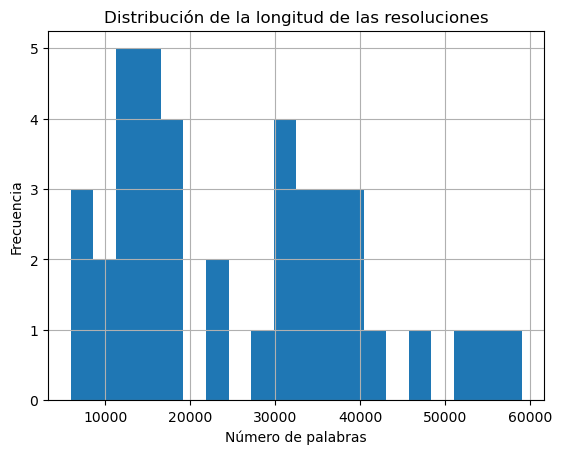

In [10]:
import matplotlib.pyplot as plt

df["longitud_texto"].hist(bins=20)
plt.title("Distribución de la longitud de las resoluciones")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

Asimismo, se identificó que la resolución más corta contiene 5,928 caracteres, mientras que la más extensa alcanza 59,026 caracteres. La diferencia entre la media y la mediana sugiere la presencia de algunos documentos particularmente extensos que influyen en el valor promedio.
Este análisis permitió obtener una primera aproximación a las características del conjunto de datos y sirvió como base para las etapas posteriores del análisis exploratorio.


### Boxplot de la longitud del texto

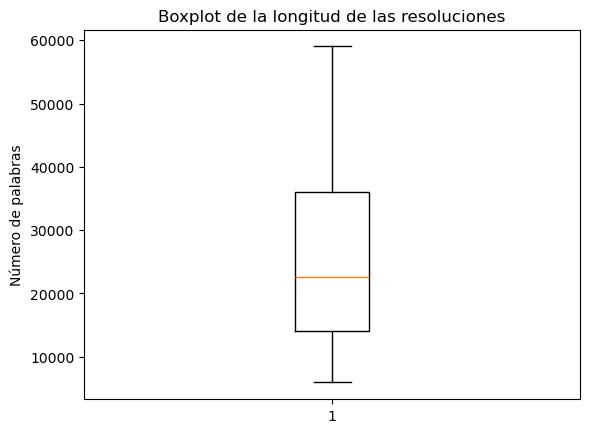

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df["longitud_texto"].dropna())
plt.title("Boxplot de la longitud de las resoluciones")
plt.ylabel("Número de palabras")
plt.show()

### Limpiar texto

In [12]:
#Crear una función para limpiar texto

import re

def limpiar_texto(texto):
    texto = texto.lower()  # pasar a minúsculas
    texto = re.sub(r'[^\w\s]', '', texto)  # quitar puntuación
    texto = re.sub(r'\d+', '', texto)  # quitar números
    return texto

In [13]:
#Aplicarlo al dataframe
df['texto_limpio'] = df['texto'].apply(limpiar_texto)

In [14]:
df['texto_limpio'][0][:500]

'amparo directo \nquejosa total play\ntelecomunicaciones\nsociedad anónima de capital\nvariable\nponente ministro luis maría aguilar morales\nsecretario javier eduardo estrever ramos\ncolaboró diana laura rouzaud anaya\níndice temático\napartado criterio y decisión págs\nrelación de hechos relevantes \nantecedentes y\ni del asunto y trámite en este\ntrámite\ntribunal constitucional\nla segunda sala de la \nii competencia suprema corte de justicia de la\nnación es competente\nexistencia del acto existe el acto recl'

## Contar palabras más frecuentes

In [15]:
#Juntar todos los textos
texto_total = " ".join(df['texto_limpio'])
palabras = texto_total.split()

In [16]:
#Contar frecuencia de palabras
from collections import Counter

frecuencias = Counter(palabras)
frecuencias.most_common(20)

[('de', 81249),
 ('la', 51284),
 ('que', 33473),
 ('en', 30582),
 ('el', 29229),
 ('y', 22718),
 ('a', 20119),
 ('los', 16351),
 ('del', 15806),
 ('se', 14712),
 ('por', 12714),
 ('las', 11673),
 ('con', 8119),
 ('no', 7748),
 ('para', 7505),
 ('su', 7453),
 ('al', 7400),
 ('o', 6599),
 ('lo', 6142),
 ('una', 5775)]

### Quitar palabras vacías

In [17]:
pip install nltk

In [18]:
# Llamamos la librería nltk para el procesamiento del lenguaje natural y descargamos el paquete stopwords para eliminar palabras vacías
# Hacemos un conteo de las palabras mas frecuentes que no sean un stopword
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stopwords_es = set(stopwords.words('spanish'))

palabras_filtradas = [p for p in palabras if p not in stopwords_es and len(p) > 3]

frecuencias = Counter(palabras_filtradas)
frecuencias.most_common(20)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP_USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('amparo', 5279),
 ('directo', 4034),
 ('derecho', 3373),
 ('artículo', 3313),
 ('sala', 2816),
 ('parte', 2317),
 ('derechos', 2262),
 ('juicio', 2038),
 ('caso', 2033),
 ('federal', 1892),
 ('daño', 1861),
 ('persona', 1719),
 ('primera', 1592),
 ('justicia', 1541),
 ('sentencia', 1523),
 ('tribunal', 1507),
 ('personas', 1462),
 ('debe', 1429),
 ('civil', 1419),
 ('responsable', 1308)]

In [19]:
# Consultamos las 20 palabras que aparecen más frecuentes en los amparos
top_palabras = frecuencias.most_common(20)
top_palabras

[('amparo', 5279),
 ('directo', 4034),
 ('derecho', 3373),
 ('artículo', 3313),
 ('sala', 2816),
 ('parte', 2317),
 ('derechos', 2262),
 ('juicio', 2038),
 ('caso', 2033),
 ('federal', 1892),
 ('daño', 1861),
 ('persona', 1719),
 ('primera', 1592),
 ('justicia', 1541),
 ('sentencia', 1523),
 ('tribunal', 1507),
 ('personas', 1462),
 ('debe', 1429),
 ('civil', 1419),
 ('responsable', 1308)]

In [20]:
#Separar palabras y valores
palabras = [p[0] for p in top_palabras]
conteos = [p[1] for p in top_palabras]

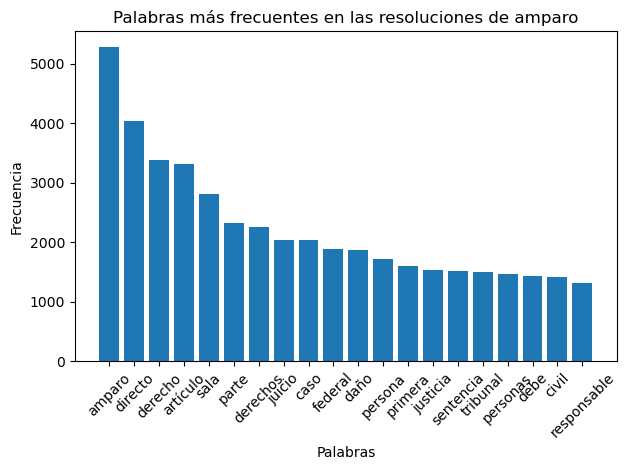

In [21]:
#Gráficamos
import matplotlib.pyplot as plt

plt.figure()
plt.bar(palabras, conteos)
plt.xticks(rotation=45)
plt.title("Palabras más frecuentes en las resoluciones de amparo")
plt.ylabel("Frecuencia")
plt.xlabel("Palabras")
plt.tight_layout()
plt.show()


### Definir un catálogo inicial de errores procesales
En esta sección, se profundiza en el análisis cualitativo del contenido de las resoluciones con el propósito de identificar patrones lingüísticos asociados a posibles errores procesales. A diferencia de un enfoque basado únicamente en categorías predefinidas, se adopta una aproximación exploratoria que parte del lenguaje efectivamente utilizado en los textos. Esto permite reconocer cómo los órganos jurisdiccionales describen, argumentan o justifican situaciones que podrían corresponder a irregularidades procesales, aun cuando no se nombren explícitamente. A partir de esta observación, se construye un catálogo de términos y expresiones representativas que servirá como base para el análisis posterior.
Se definió un conjunto de categorías de errores procesales basadas en conceptos jurídicos comúnmente utilizados en la literatura y en la doctrina, tales como violación al debido proceso, falta de fundamentación, prueba ilícita o insuficiencia probatoria. 

In [22]:
# Iniciamos el catálogo con terminos que podríamos encontrar, relacionados a los errores procesales. Creamos un diccionario:
errores_procesales = [
    "violacion al debido proceso",
    "falta de fundamentacion",
    "falta de motivacion",
    "prueba ilicita",
    "insuficiencia probatoria",
    "inexacta aplicacion de la ley",
    "valoracion indebida de la prueba",
    "violacion a la presuncion de inocencia",
    "defensa inadecuada",
    "falta de exhaustividad"
]

In [23]:
# Buscamos los términos del diccionario previamente creado en el texto del amparo
def buscar_errores(texto):
    encontrados = []
    for error in errores_procesales:
        if error in texto:
            encontrados.append(error)
    return encontrados

In [24]:
df["errores_detectados"] = df["texto_limpio"].apply(buscar_errores)

In [25]:
# Consultamos cuántos de los errores del diccionario se encontraron en cada amparo y pedimos que nos muestre el resultado de los primeros 5
df[["archivo","errores_detectados"]].head()

,archivo,errores_detectados
0,2_275703_6975_firmado.pdf,[]
1,2_277422_5407_firmado.pdf,[]
2,2_282000_6705_firmado.pdf,[]
3,2_283663_5866_firmado.pdf,[]
4,2_284030_5426_firmado.pdf,[]


Durante la exploración de los documentos se observó que este tipo de expresiones no aparecía de manera literal en la mayoría de las resoluciones, ya que los órganos jurisdiccionales suelen describir estas situaciones mediante razonamientos narrativos y no mediante categorías estandarizadas.
Por esta razón, fue necesario ampliar el conjunto de palabras clave, incorporando expresiones asociadas a la valoración de pruebas, deficiencias en la argumentación y referencias a la fundamentación jurídica, tales como “no valorar”, “deficiencia”, “inconsistente” o “fundamento legal”. 
Este ajuste permitió detectar la presencia de estas situaciones en diversos documentos, lo que confirmó la pertinencia de utilizar un enfoque flexible en la identificación de patrones textuales.

In [26]:
#Ampliamos diccionario de palabras clave
errores_procesales = {
    "valoracion_prueba": [
        "no valorar",
        "valoracion",
        "pruebas documentales",
        "indebida valoracion"
    ],
    
    "deficiencia_argumentacion": [
        "deficiencia",
        "inconsistente",
        "inconsistentes",
        "contrario a lo expuesto"
    ],
    
    "fundamentacion": [
        "fundamento legal",
        "fundamentacion",
        "motivacion"
    ]
}


In [27]:
#Misma función
def buscar_errores(texto):
    encontrados = []
    
    for tipo_error, palabras in errores_procesales.items():
        for palabra in palabras:
            if palabra in texto:
                encontrados.append(tipo_error)
                break
    
    return encontrados

In [28]:
df["errores_detectados"] = df["texto_limpio"].apply(buscar_errores)

In [29]:
# Consultamos cuántos de los errores del diccionario se encontraron en cada amparo y pedimos que nos muestre el resultado de los primeros 5
df[["archivo","errores_detectados"]].head()

,archivo,errores_detectados
0,2_275703_6975_firmado.pdf,"[valoracion_prueba, deficiencia_argumentacion,..."
1,2_277422_5407_firmado.pdf,[deficiencia_argumentacion]
2,2_282000_6705_firmado.pdf,"[valoracion_prueba, deficiencia_argumentacion,..."
3,2_283663_5866_firmado.pdf,[]
4,2_284030_5426_firmado.pdf,[valoracion_prueba]


Los resultados obtenidos mostraron que algunas de estas categorías aparecen con mayor frecuencia que otras, lo cual constituye una primera aproximación a la identificación de patrones en las resoluciones de amparo y proporciona una base inicial para la construcción del catálogo de posibles errores procesales.

### Contar los errores detectados

In [30]:
#Juntamos todos los errores en una sola lista y contamos cuantas veces aparece cada error
from collections import Counter

todos_errores = []

for lista in df["errores_detectados"]:
    todos_errores.extend(lista)

contador_errores = Counter(todos_errores)

contador_errores

Counter({'deficiencia_argumentacion': 30,
         'valoracion_prueba': 8,
         'fundamentacion': 4})

In [31]:
#Convertir a listas para graficar
errores = list(contador_errores.keys())
frecuencias = list(contador_errores.values())

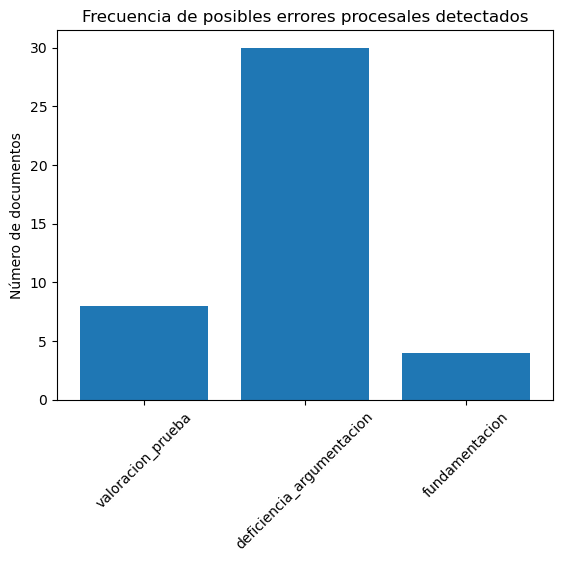

In [32]:
#Graficar
import matplotlib.pyplot as plt

plt.figure()
plt.bar(errores, frecuencias)
plt.xticks(rotation=45)
plt.title("Frecuencia de posibles errores procesales detectados")
plt.ylabel("Número de documentos")
plt.show()

El gráfico de frecuencias muestra que la deficiencia en la argumentación constituye el patrón más recurrente dentro del conjunto analizado, apareciendo en la mayoría de los documentos. En contraste, las referencias relacionadas con la valoración de pruebas presentan una frecuencia considerablemente menor, mientras que las alusiones a problemas de fundamentación aparecen en un número reducido de casos.
Estos resultados sugieren que, dentro del conjunto de resoluciones analizadas, las irregularidades procesales se vinculan principalmente con aspectos argumentativos de la resolución judicial, más que con fallas formales de fundamentación o exclusivamente probatorias. Desde una perspectiva jurídica, esto podría indicar que la debilidad en la construcción lógica del razonamiento judicial constituye un factor relevante en la concesión del amparo en los casos estudiados.
El gráfico de frecuencias muestra que la deficiencia en la argumentación constituye el patrón más recurrente dentro del conjunto analizado, apareciendo en la mayoría de los documentos. En contraste, las referencias relacionadas con la valoración de pruebas presentan una frecuencia considerablemente menor, mientras que las alusiones a problemas de fundamentación aparecen en un número reducido de casos.
Estos resultados sugieren que, dentro del conjunto de resoluciones analizadas, las irregularidades procesales se vinculan principalmente con aspectos argumentativos de la resolución judicial, más que con fallas formales de fundamentación o exclusivamente probatorias. Desde una perspectiva jurídica, esto podría indicar que la debilidad en la construcción lógica del razonamiento judicial constituye un factor relevante en la concesión del amparo en los casos estudiados.


### Mostrar ejemplos de texto donde se ven los errores

In [33]:
#Dividir cada documento en párrafos
def dividir_parrafos(texto):
    return texto.split("\n")

In [34]:
df["parrafos"] = df["texto"].apply(dividir_parrafos)

In [35]:
#Buscar errores dentro de los párrafos
def buscar_parrafos_error(parrafos):
    resultados = []
    
    for parrafo in parrafos:
        parrafo_lower = parrafo.lower()       
        
        for tipo_error, palabras in errores_procesales.items():
            for palabra in palabras:
                if palabra in parrafo_lower:
                    resultados.append((tipo_error, parrafo.strip()))
                    break
    
    return resultados

In [36]:
#Aplicamos al dataframe
df["ejemplos_errores"] = df["parrafos"].apply(buscar_parrafos_error)

In [37]:
#Muestra ejemplos
for ejemplos in df["ejemplos_errores"]:
    if ejemplos:
        print("\n--- Ejemplo encontrado ---\n")
        print(ejemplos[0][1][:500])
        break


--- Ejemplo encontrado ---

tanto, ante la deficiencia de sus planteamientos se sigue la consecuencia


In [38]:
#Extraer un ejemplo por tipo de error
ejemplos_por_error = {}

for lista in df["ejemplos_errores"]:
    for tipo, parrafo in lista:
        if tipo not in ejemplos_por_error:
            ejemplos_por_error[tipo] = parrafo

ejemplos_por_error

{'deficiencia_argumentacion': 'tanto, ante la deficiencia de sus planteamientos se sigue la consecuencia',
 'fundamentacion': 'por carecer de fundamento legal esa solicitud y, con independencia de lo',
 'valoracion_prueba': 'deficiencia al no valorar las pruebas documentales que aportó para con ello,'}

In [39]:
# 1. Ver qué columnas hay realmente
print("Columnas disponibles:", df.columns.tolist())

# 2. Buscar si hay algo parecido (por si hay espacios o mayúsculas)
import difflib
matches = difflib.get_close_matches('tiene_error', df.columns.tolist())
if matches:
    print(f"¿Quizás quisiste decir: {matches}?")
else:
    print("No se encontró nada similar.")

Columnas disponibles: ['archivo', 'texto', 'longitud_texto', 'texto_limpio', 'errores_detectados', 'parrafos', 'ejemplos_errores']
No se encontró nada similar.


In [40]:
df["errores_detectados"].value_counts()

errores_detectados
[deficiencia_argumentacion]                                       22
[]                                                                 8
[valoracion_prueba, deficiencia_argumentacion]                     5
[valoracion_prueba, deficiencia_argumentacion, fundamentacion]     2
[valoracion_prueba]                                                1
[fundamentacion]                                                   1
[deficiencia_argumentacion, fundamentacion]                        1
Name: count, dtype: int64

In [41]:
# Creamos la columna: True si la lista tiene elementos, False si está vacía
df['tiene_error'] = df['errores_detectados'].apply(lambda x: len(x) > 0)

# Ahora ya puedes ejecutar tu comando original sin errores:
print(df["tiene_error"].value_counts())

tiene_error
True     32
False     8
Name: count, dtype: int64


In [42]:
df["tiene_error"].value_counts()

tiene_error
True     32
False     8
Name: count, dtype: int64

In [44]:
#Numero de errores por documento
df["num_errores"] = df["errores_detectados"].apply(len)
df["num_errores"].describe()

count    40.000000
mean      1.050000
std       0.749359
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
Name: num_errores, dtype: float64

In [45]:
#Distribución
df["num_errores"].value_counts()

num_errores
1    24
0     8
2     6
3     2
Name: count, dtype: int64

In [46]:
df["num_errores"].describe()

count    40.000000
mean      1.050000
std       0.749359
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
Name: num_errores, dtype: float64

C:\Users\HP_USER\AppData\Local\Temp\ipykernel_28472\3818292689.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='conteo_errores', palette='viridis')


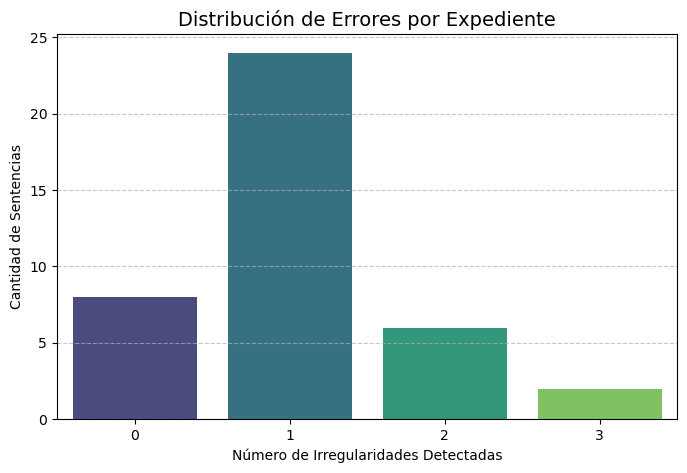

In [47]:
import seaborn as sns

# Creamos la columna de conteo
df['conteo_errores'] = df['errores_detectados'].apply(len)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='conteo_errores', palette='viridis')
plt.title('Distribución de Errores por Expediente', fontsize=14)
plt.xlabel('Número de Irregularidades Detectadas')
plt.ylabel('Cantidad de Sentencias')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

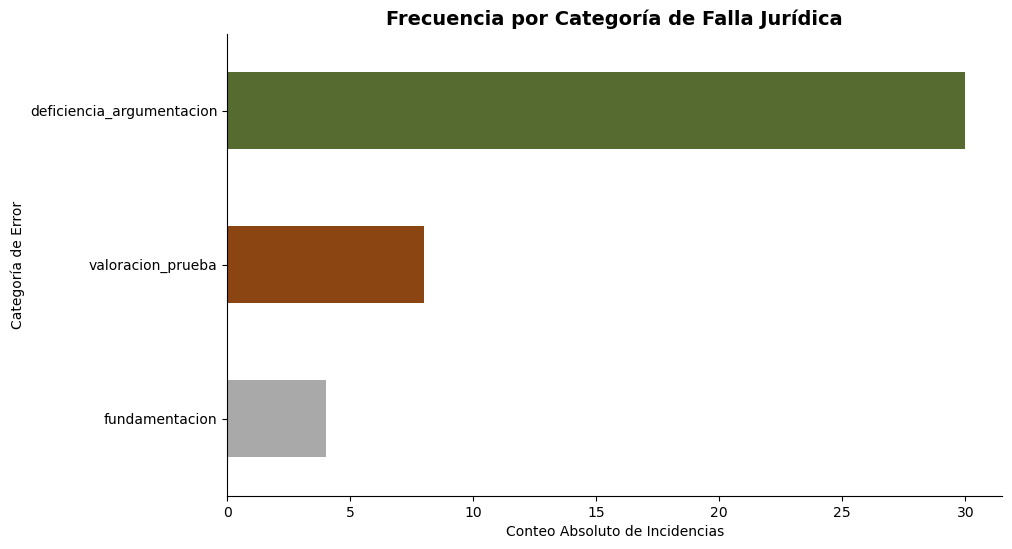

In [48]:
# Definimos los colores personalizados
colores_tierra = ['#556B2F', '#8B4513', '#A9A9A9', '#2F4F4F'] # Oliva, Café, Gris

frecuencia_errores = df['errores_detectados'].explode().value_counts()

plt.figure(figsize=(10, 6))
frecuencia_errores.plot(kind='barh', color=colores_tierra)

plt.title('Frecuencia por Categoría de Falla Jurídica', fontsize=14, fontweight='bold')
plt.xlabel('Conteo Absoluto de Incidencias')
plt.ylabel('Categoría de Error')
plt.gca().invert_yaxis()
sns.despine() # Limpia los bordes de la gráfica
plt.show()

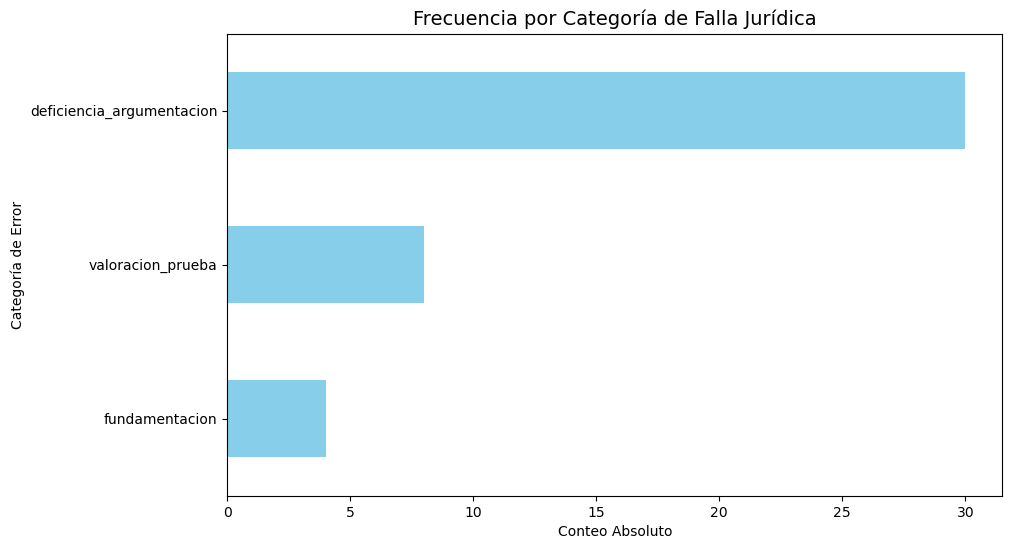

In [49]:
# Expandimos las listas y contamos
frecuencia_errores = df['errores_detectados'].explode().value_counts()

plt.figure(figsize=(10, 6))
frecuencia_errores.plot(kind='barh', color='skyblue')
plt.title('Frecuencia por Categoría de Falla Jurídica', fontsize=14)
plt.xlabel('Conteo Absoluto')
plt.ylabel('Categoría de Error')
plt.gca().invert_yaxis()  # Para que el mayor salga arriba
plt.show()

In [50]:
print(df.columns.tolist())

['archivo', 'texto', 'longitud_texto', 'texto_limpio', 'errores_detectados', 'parrafos', 'ejemplos_errores', 'tiene_error', 'num_errores', 'conteo_errores']


In [51]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


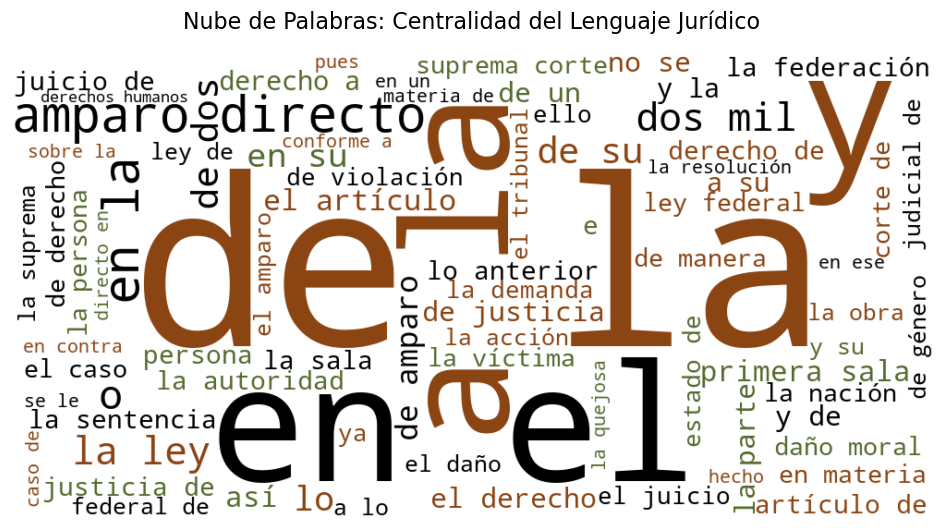

In [52]:
import random
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Definimos tus colores: Oliva, Café, Negro
def color_paleta_juridica(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(["#556B2F", "#8B4513", "#000000"])

# Unimos el texto
texto_total = " ".join(df['texto_limpio'].astype(str))

# Palabras que no aportan valor jurídico (puedes añadir más)
stopwords_mx = set(["que", "del", "por", "para", "con", "una", "este", "esta", "los", "las", "como", "esta", "estos"])

wc = WordCloud(
    width=1000, height=500,
    background_color='white',
    stopwords=stopwords_mx,
    max_words=80,
    color_func=color_paleta_juridica
).generate(texto_total)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras: Centralidad del Lenguaje Jurídico', fontsize=16, pad=20)
plt.show()

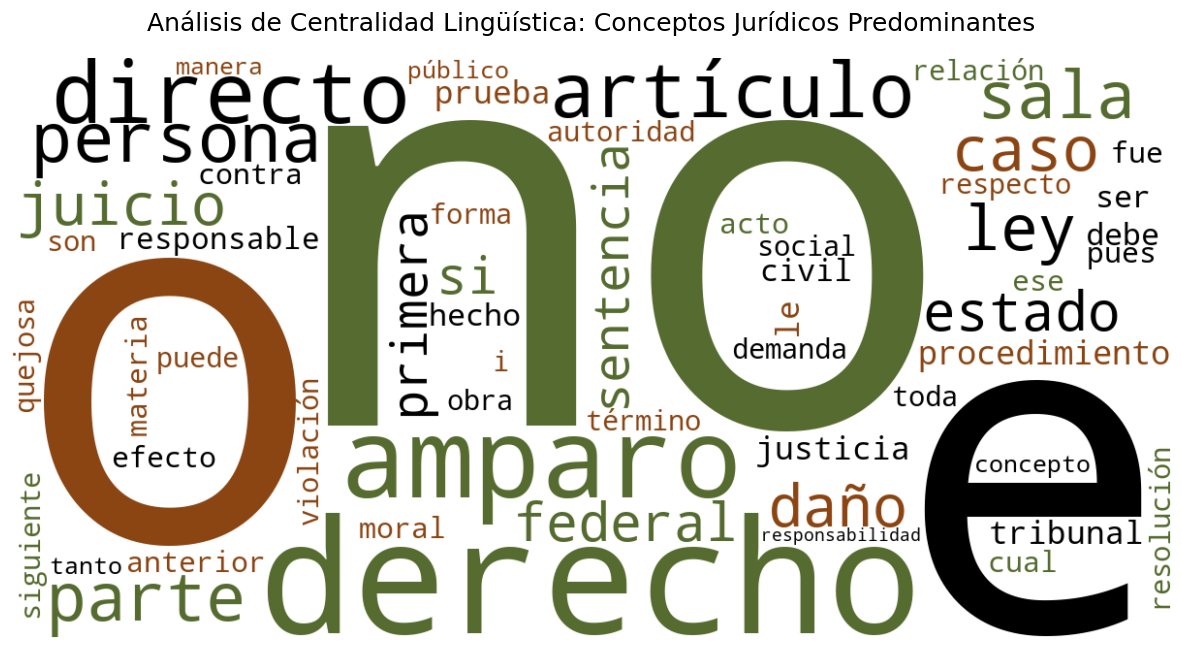

In [54]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random

# 1. Definimos tus colores profesionales
def color_paleta_juridica(word, font_size, position, orientation, random_state=None, **kwargs):
    return random.choice(["#556B2F", "#8B4513", "#000000"])

# 2. Lista extendida de palabras que debemos quitar (Stopwords)
stopwords_mx = set([
    "que", "del", "por", "para", "con", "una", "este", "esta", "los", "las", 
    "como", "estos", "estas", "sus", "una", "uno", "sobre", "todo", "también",
    "entre", "cuando", "desde", "hasta", "donde", "pero", "hacia", "ella", "ellos",
    "de", "la", "en", "el", "y", "a", "lo", "su", "al", "así", "ya", "dos", "mil",
    "ello", "ante", "nos", "se", "un", "bien", "sin", "más", "está", "esto"
])

# 3. Generar la nube de nuevo
texto_total = " ".join(df['texto_limpio'].astype(str))

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    stopwords=stopwords_mx, # Aplicamos la limpieza
    max_words=60,
    collocations=False, # Evita que se repitan frases como "de la"
    color_func=color_paleta_juridica,
    font_path=None # Puedes poner una ruta a una fuente Serif para que se vea más formal
).generate(texto_total)

plt.figure(figsize=(15, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Análisis de Centralidad Lingüística: Conceptos Jurídicos Predominantes', fontsize=18, pad=20)
plt.show()

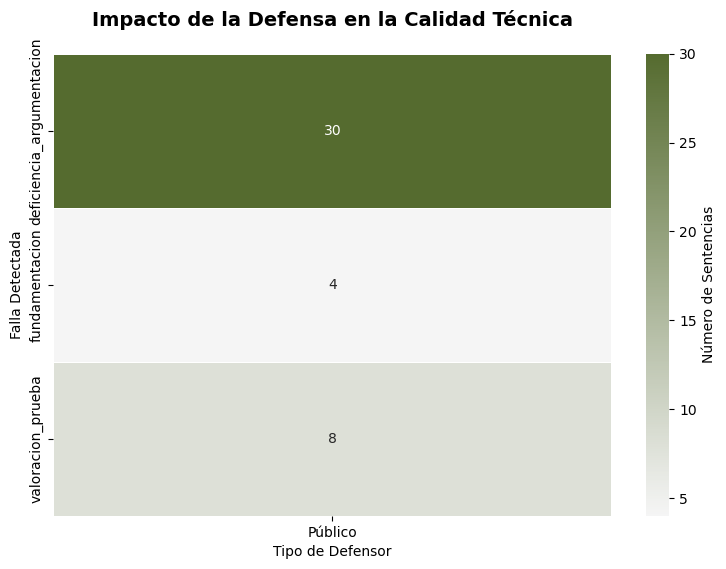

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Identificar el defensor (por si acaso no se guardó la columna)
def etiquetar_defensor(texto):
    t = str(texto).lower()
    if any(p in t for p in ['oficio', 'público', 'defensoría', 'publico']):
        return 'Público'
    return 'Privado/Particular'

df['tipo_defensor'] = df['texto'].apply(etiquetar_defensor)

# 2. Expandir errores y RESETEAR EL ÍNDICE (Esto evita el ValueError)
df_exp = df.explode('errores_detectados').reset_index(drop=True)

# 3. Crear la matriz de correlación
# Usamos values de las columnas directamente para evitar problemas de reindexación
matriz = pd.crosstab(df_exp['errores_detectados'], df_exp['tipo_defensor'])

# 4. Estética Profesional (Oliva y Gris)
cmap_personalizado = LinearSegmentedColormap.from_list("oliva_gris", ["#F5F5F5", "#556B2F"])

plt.figure(figsize=(9, 6))
sns.heatmap(matriz, 
            annot=True, 
            cmap=cmap_personalizado, 
            fmt='d', 
            linewidths=.5,
            cbar_kws={'label': 'Número de Sentencias'})

plt.title('Impacto de la Defensa en la Calidad Técnica', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo de Defensor')
plt.ylabel('Falla Detectada')
plt.show()

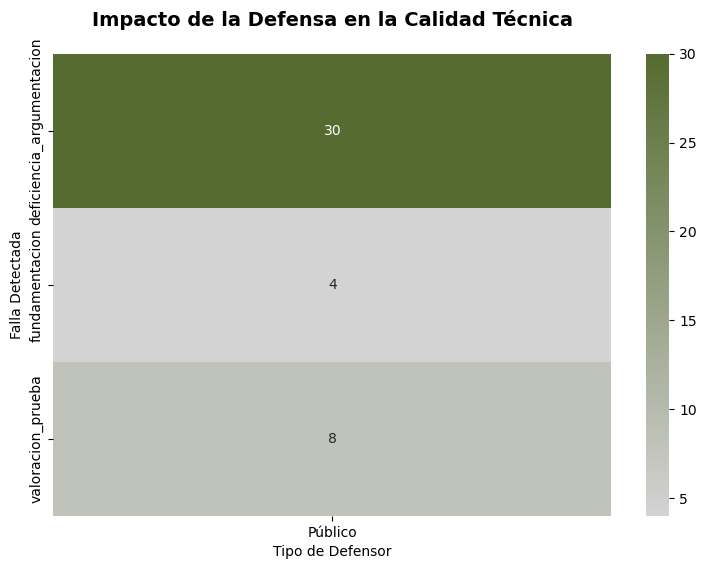

In [56]:
# 1. Intentamos identificar el tipo de defensor buscando en el texto original
def etiquetar_defensor(texto):
    t = str(texto).lower()
    if 'oficio' in t or 'público' in t or 'defensoría' in t:
        return 'Público'
    else:
        # Por descarte o palabras clave de privado
        return 'Privado/Particular'

df['tipo_defensor'] = df['texto'].apply(etiquetar_defensor)

# 2. Ahora generamos la matriz de correlación (Heatmap)
df_exp = df.explode('errores_detectados')
matriz = pd.crosstab(df_exp['errores_detectados'], df_exp['tipo_defensor'])

# 3. Gráfica con tus colores (Oliva y Gris)
from matplotlib.colors import LinearSegmentedColormap
cmap_personalizado = LinearSegmentedColormap.from_list("oliva_gris", ["#D3D3D3", "#556B2F"])

plt.figure(figsize=(9, 6))
sns.heatmap(matriz, annot=True, cmap=cmap_personalizado, fmt='d')
plt.title('Impacto de la Defensa en la Calidad Técnica', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo de Defensor')
plt.ylabel('Falla Detectada')
plt.show()

### Errores por tipo de delito

Con el objetivo de analizar la relación entre el tipo de delito y las irregularidades procesales detectadas, se construirá un diccionario de términos basado en palabras clave asociadas a los principales delitos. Esta clasificación permitirá identificar patrones en los errores procesales según el contexto del caso.




In [57]:
#Creamos un diccionario
delitos = {
    "robo": ["robo", "hurto", "asalto", "sustracción", "sustraer", "despojo", "despojar"],
    "homicidio": ["homicidio", "asesinato", "privación de la vida"],
    "fraude": ["fraude", "estafa"],
    "extorsión": ["extorsión", "coacción", "coerción"],
    "violencia": ["violencia"],
    
}

In [58]:
#Hacemos la búsqueda de los términos declarados en el diccionario
def detectar_delito(texto):
    for delito, palabras in delitos.items():
        for palabra in palabras:
            if palabra in texto.lower():
                return delito
    return "otro"

df["delito"] = df["texto"].apply(detectar_delito)

In [59]:
#Contamos cuantas veces aparecen los términos de nuestro diccionario en los amparos
df["delito"].value_counts()

delito
robo         27
violencia     6
otro          4
extorsión     2
homicidio     1
Name: count, dtype: int64

In [60]:
#Usamos explode para separar listas en filas
df_exploded = df.explode("errores_detectados")

In [61]:
#Creamos una tabla cruzada

import pandas as pd

tabla = pd.crosstab(
    df_exploded["delito"],
    df_exploded["errores_detectados"]
)

Con el objetivo de analizar la relación entre el tipo de delito y las irregularidades procesales detectadas, se construyó un mapa de calor que permite visualizar de manera conjunta la frecuencia de cada tipo de error en función de la clasificación de los delitos. Este tipo de visualización facilita la identificación de patrones y concentraciones de errores, al representar mediante intensidades de color la magnitud de las coincidencias entre ambas variables.

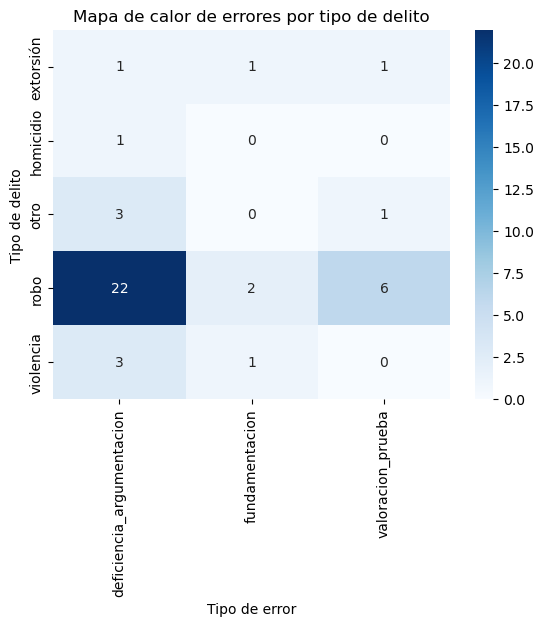

In [62]:
#Representamos los resultados en un mapa de calor

import seaborn as sns

sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")

plt.title("Mapa de calor de errores por tipo de delito")
plt.xlabel("Tipo de error")
plt.ylabel("Tipo de delito")

plt.show()

Se destaca que en los casos clasificados como robo existe una alta concentración de deficiencias en la argumentación, lo que sugiere que este tipo de irregularidad es especialmente recurrente en este grupo de resoluciones. Asimismo, se observa que los errores relacionados con la valoración de la prueba también están presentes en menor medida dentro de esta categoría. En contraste, los demás tipos de delito presentan una frecuencia considerablemente menor de errores, lo que puede estar asociado tanto al tamaño reducido de estos grupos como a diferencias en la naturaleza de los casos. La categoría “otro” muestra una distribución más dispersa, lo que refleja las limitaciones del proceso de clasificación basado en palabras clave. En conjunto, estos resultados sugieren que las irregularidades procesales no se distribuyen de manera homogénea entre los distintos tipos de delito, sino que tienden a concentrarse en ciertos contextos específicos, particularmente en aquellos relacionados con delitos de robo.

## Interpretación jurídica y práctica de los resultados
Desde una perspectiva práctica, el hecho de que la mayoría de los expedientes presente al menos un error procesal sugiere que este tipo de fallas puede desempeñar un papel relevante en la procedencia del amparo. Aunque el análisis realizado no permite establecer relaciones causales ni generalizar a todos los casos judiciales, sí permite observar que los errores procesales aparecen de manera recurrente en los expedientes concedidos.
Asimismo, la baja variabilidad en el número de errores indica que no suele existir una acumulación elevada de irregularidades; en muchos casos, la presencia de uno o pocos errores puede ser suficiente para influir en el resultado del juicio de amparo. Esto refuerza la importancia del cumplimiento estricto de las formalidades procesales dentro de los procedimientos judiciales.
Es importante señalar que, debido a que el conjunto de datos está conformado únicamente por amparos concedidos, el análisis se limita a una descripción del fenómeno dentro de este universo y no permite comparar con casos en los que el amparo fue negado. Por ello, los resultados deben interpretarse como un análisis exploratorio que identifica patrones y características presentes en los expedientes estudiados, más que como un modelo predictivo o inferencial.

In [64]:
tribunales = {
    "Tribunal Colegiado": ["tribunal colegiado"],
    "Juzgado de Distrito": ["juzgado de distrito"],
    "SCJN": ["suprema corte", "scjn"],
    "Tribunal Unitario": ["tribunal unitario"]
}

In [65]:
def detectar_tribunal(texto):
    texto = texto.lower()
    
    for tribunal, palabras in tribunales.items():
        if any(palabra in texto for palabra in palabras):
            return tribunal
    
    return "otro"

In [66]:
df["tribunal"] = df["texto"].apply(detectar_tribunal)

In [67]:
df["tribunal"].value_counts()

tribunal
Tribunal Colegiado    40
Name: count, dtype: int64